In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('data.csv')

## Full Exploratory Data Analysis (EDA)

This section performs a complete EDA on `data.csv`:
- Data loading and type checks
- Missing values and duplicates
- Target balance (`TenYearCHD`)
- Univariate analysis (numerical + categorical)
- Correlation and target relationships
- Outlier diagnostics and key insights

In [16]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')

# Load fresh copy for EDA
eda_df = pd.read_csv('data.csv', na_values=['NA', 'na', 'N/A', ''])

# Convert columns to numeric where appropriate
for col in eda_df.columns:
    converted = pd.to_numeric(eda_df[col], errors='coerce')
    if converted.notna().sum() >= max(1, int(0.95 * eda_df[col].notna().sum())):
        eda_df[col] = converted

print(f"Shape: {eda_df.shape}")
print("\nColumn types:")
print(eda_df.dtypes)

eda_df.head()

Shape: (4240, 16)

Column types:
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Duplicate rows: 0


,dtype,missing_count,missing_pct,unique_values
glucose,float64,388,9.15,143
education,float64,105,2.48,4
BPMeds,float64,53,1.25,2
totChol,float64,50,1.18,248
cigsPerDay,float64,29,0.68,33
BMI,float64,19,0.45,1364
heartRate,float64,1,0.02,73
male,int64,0,0.00,2
age,int64,0,0.00,39
currentSmoker,int64,0,0.00,2


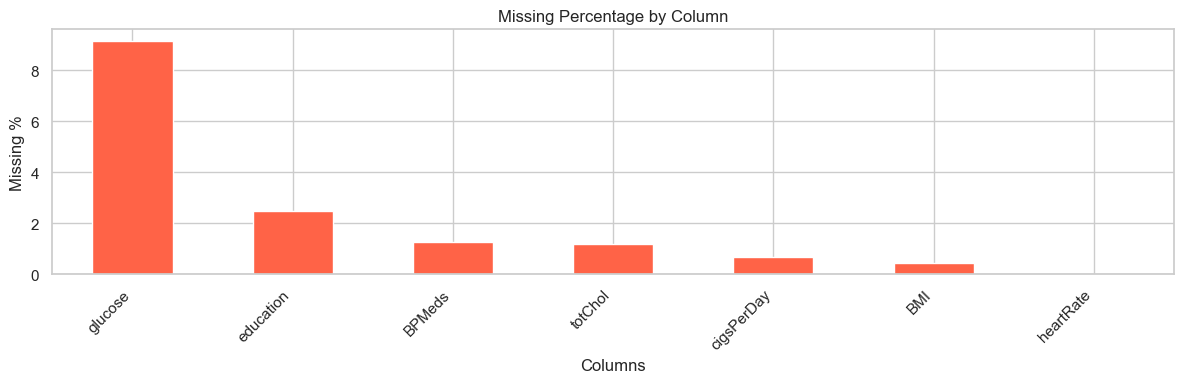

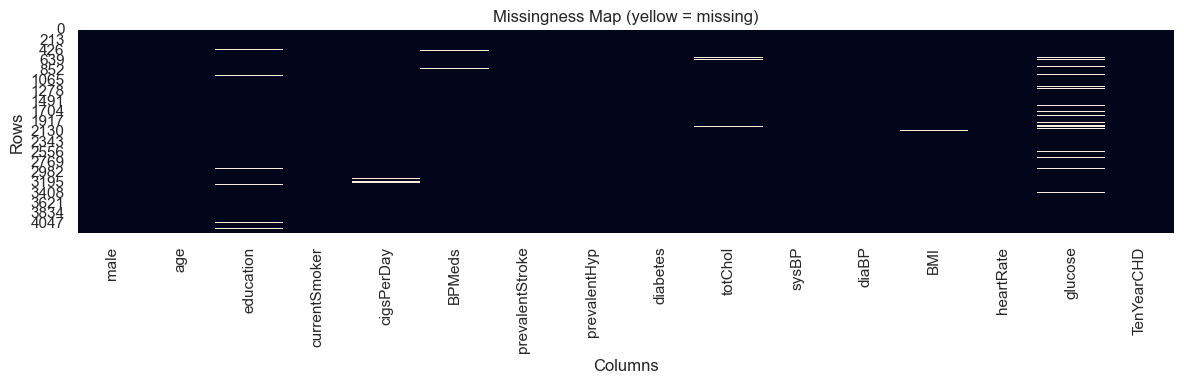

In [17]:
# Basic dataset quality checks
rows, cols = eda_df.shape
missing_count = eda_df.isnull().sum()
missing_pct = (missing_count / rows * 100).round(2)

quality_report = pd.DataFrame({
    'dtype': eda_df.dtypes.astype(str),
    'missing_count': missing_count,
    'missing_pct': missing_pct,
    'unique_values': eda_df.nunique(dropna=True)
}).sort_values('missing_pct', ascending=False)

print(f"Duplicate rows: {eda_df.duplicated().sum()}")
display(quality_report)

# Missing values visualization
plt.figure(figsize=(12, 4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title('Missing Percentage by Column')
plt.ylabel('Missing %')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Data completeness heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(eda_df.isnull(), cbar=False)
plt.title('Missingness Map (yellow = missing)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

Numerical columns (16): ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
Categorical/non-numerical columns (0): []


,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


Target distribution:


,count,pct
TenYearCHD,,
0,3596,84.81
1,644,15.19


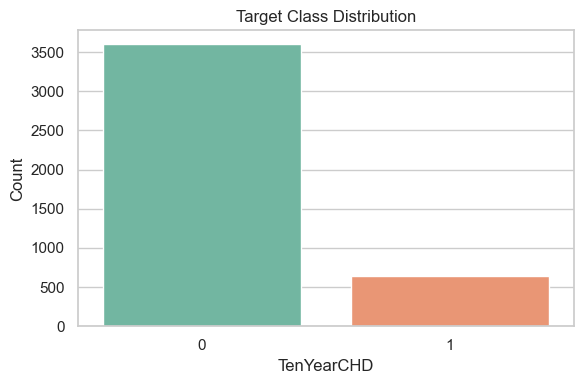

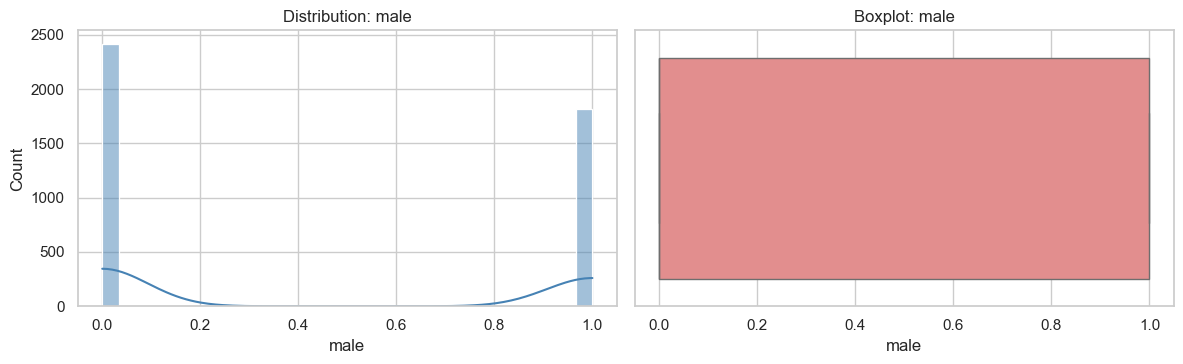

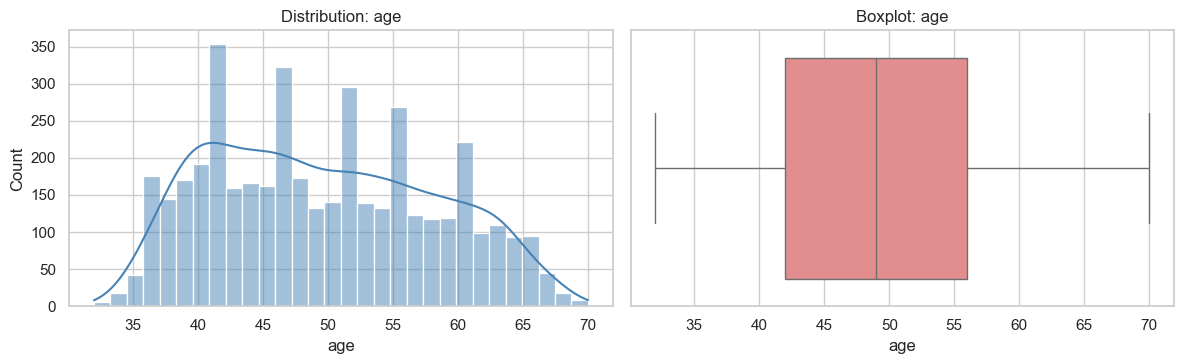

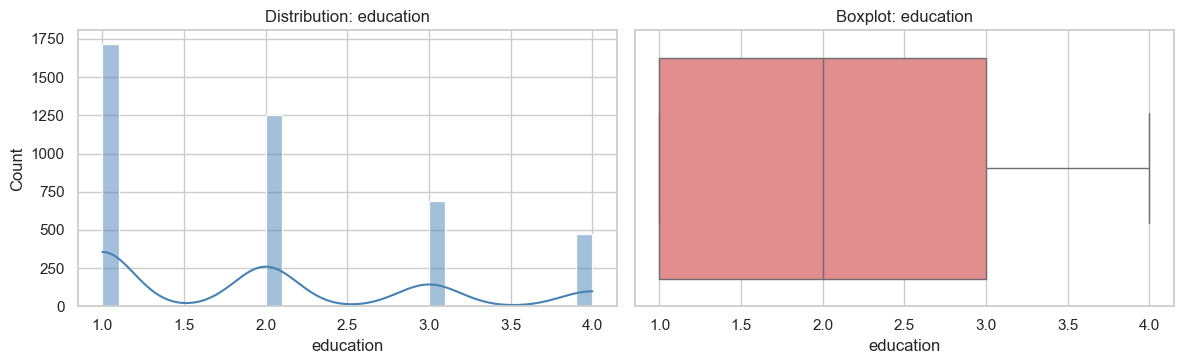

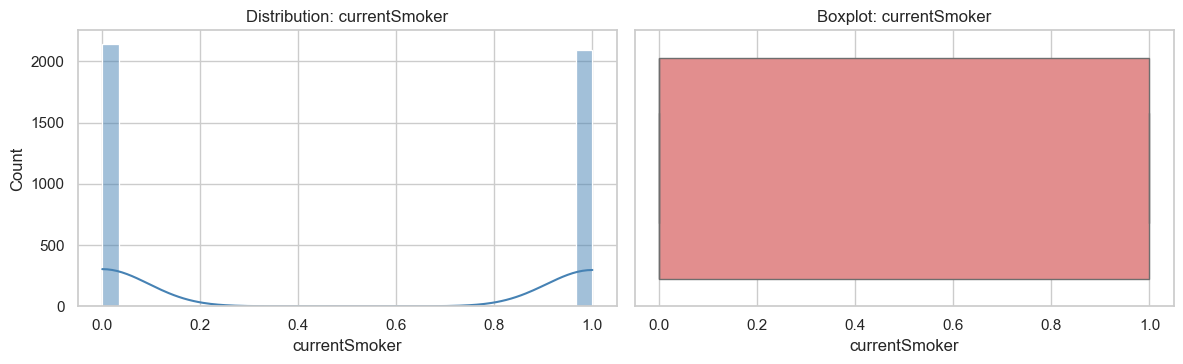

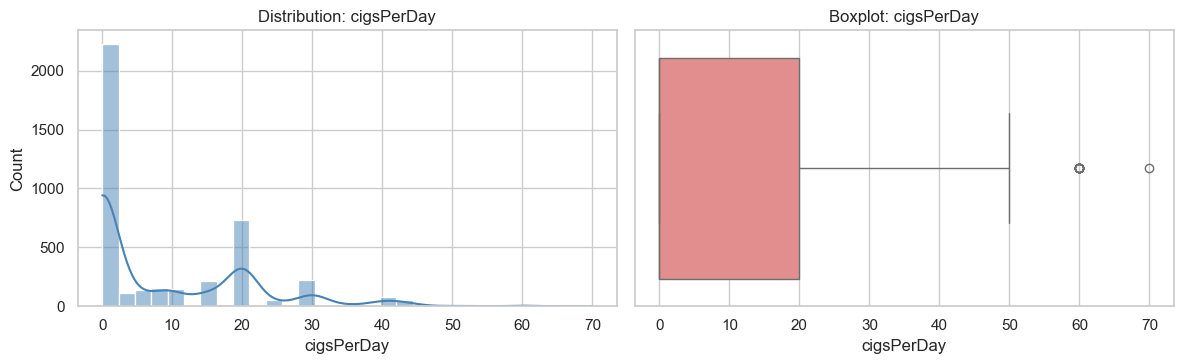

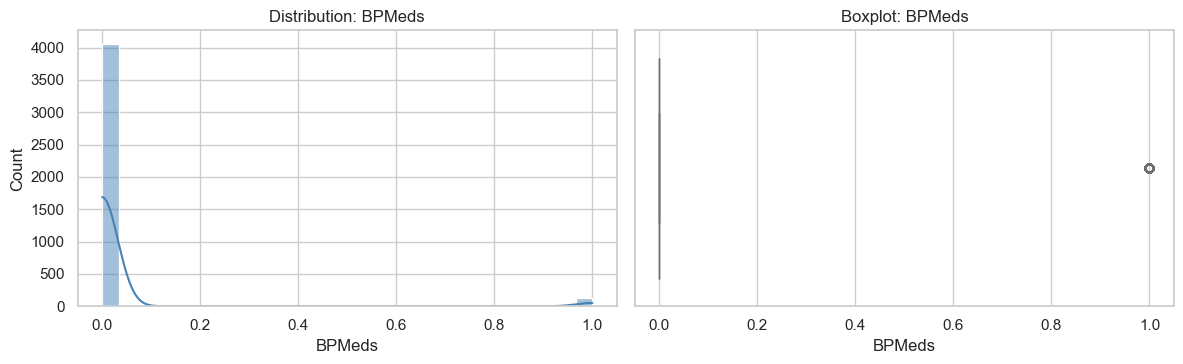

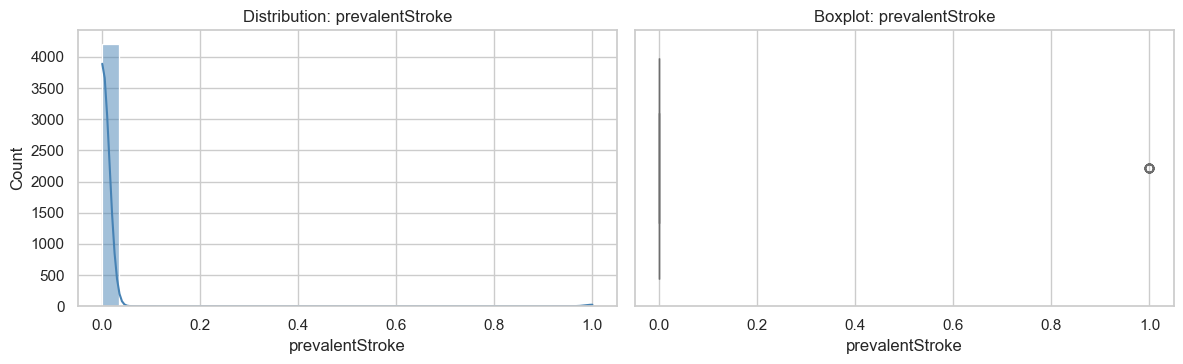

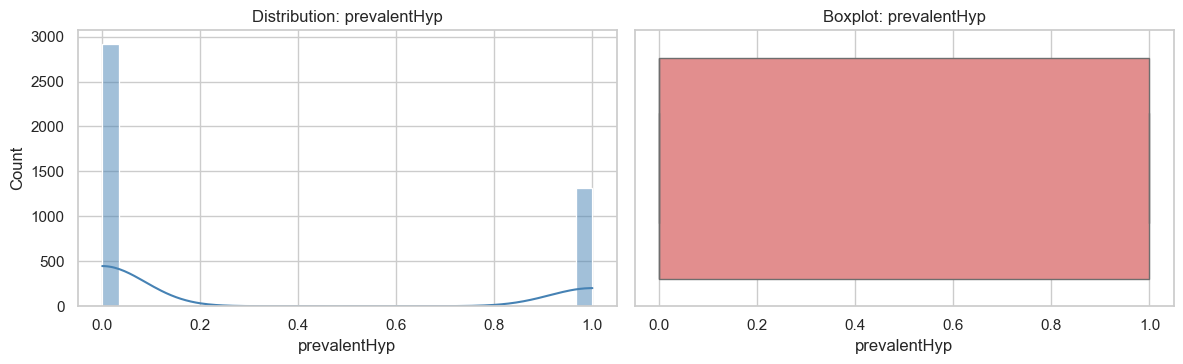

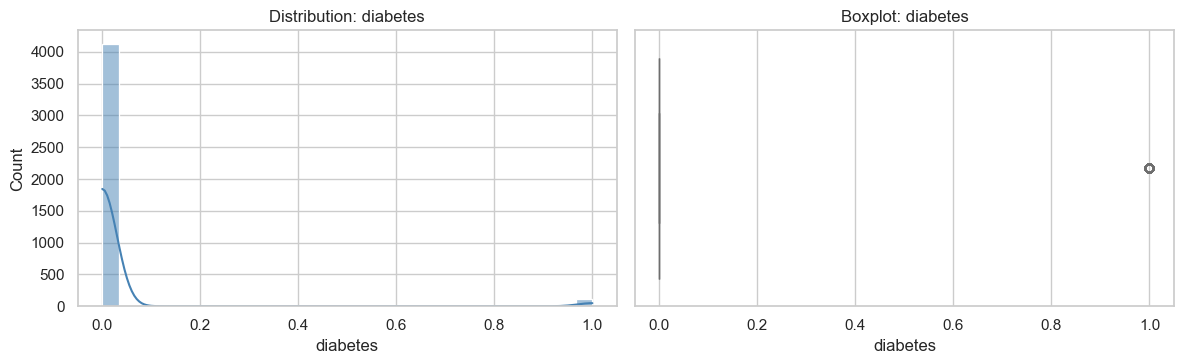

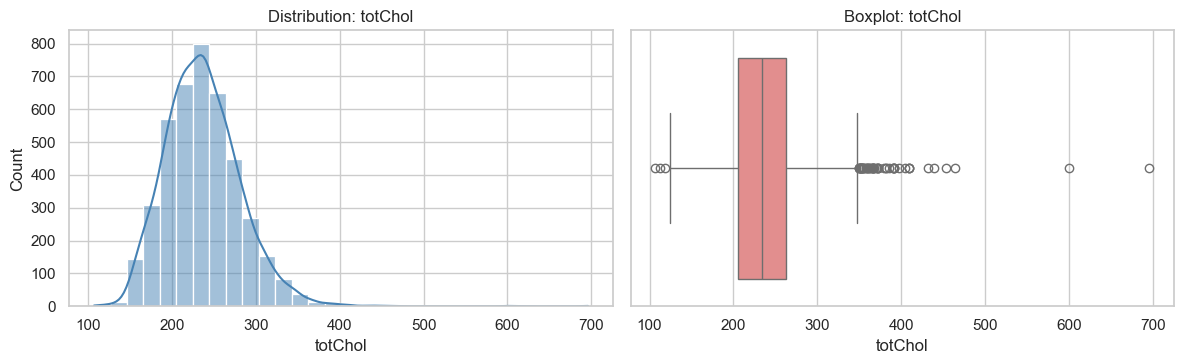

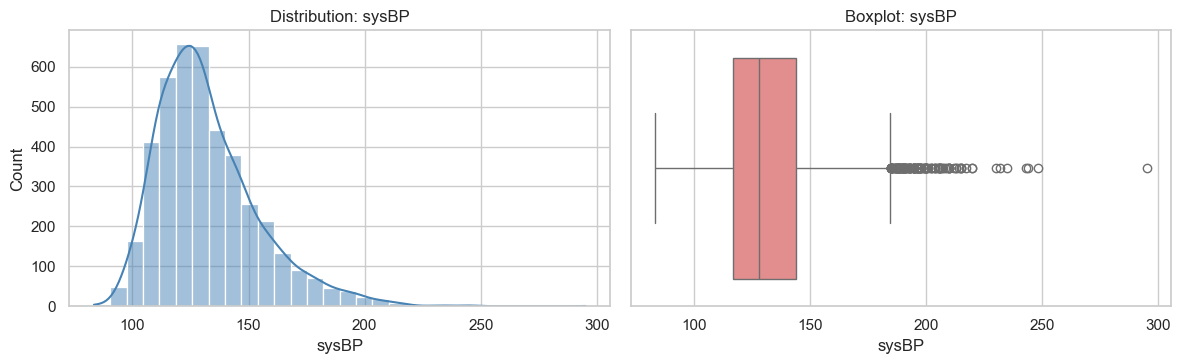

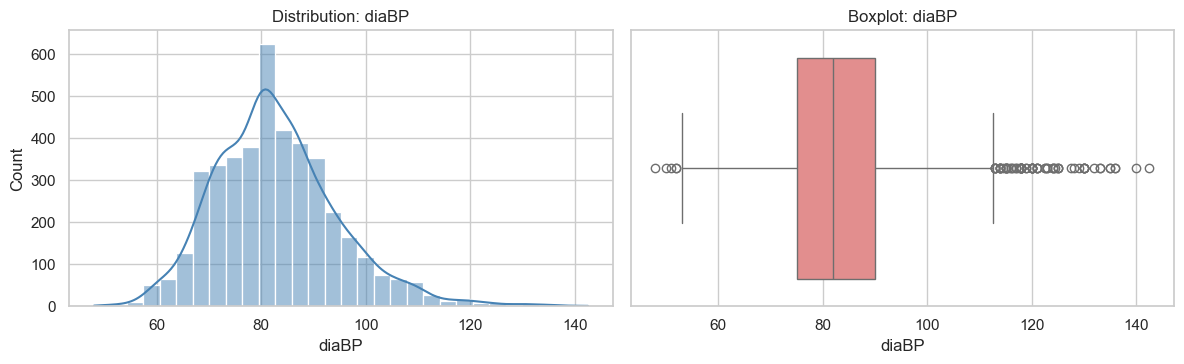

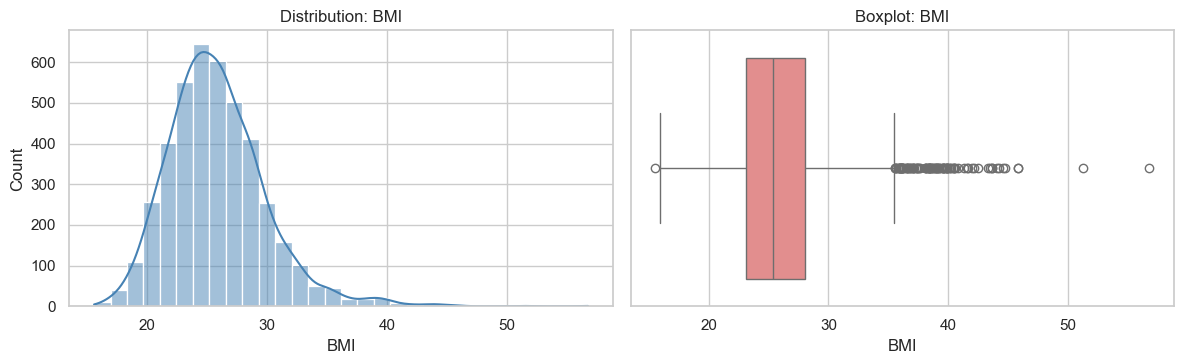

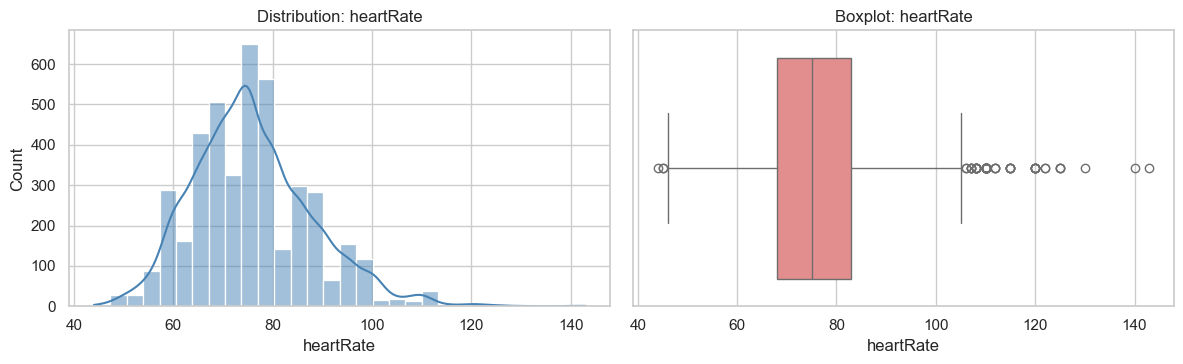

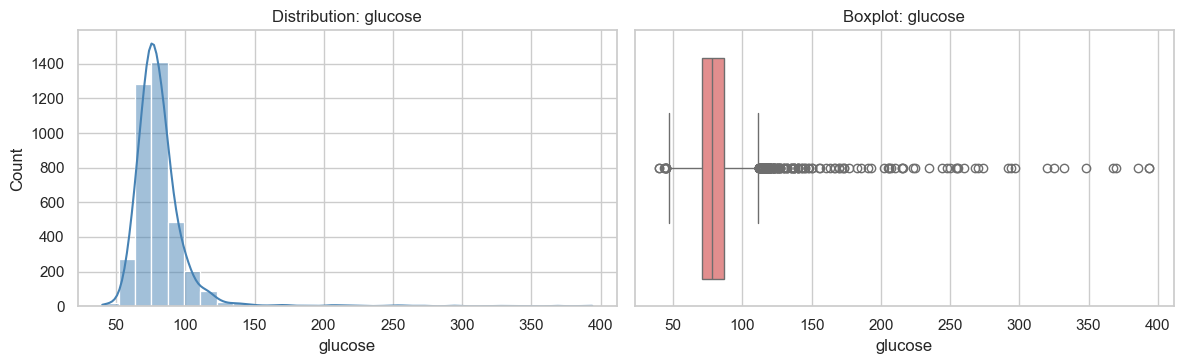

In [18]:
# Feature grouping
num_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [col for col in eda_df.columns if col not in num_cols]

print(f"Numerical columns ({len(num_cols)}): {num_cols}")
print(f"Categorical/non-numerical columns ({len(cat_cols)}): {cat_cols}")

display(eda_df[num_cols].describe().T)

# Target distribution (if available)
target_col = 'TenYearCHD' if 'TenYearCHD' in eda_df.columns else None

if target_col:
    target_dist = eda_df[target_col].value_counts(dropna=False).sort_index()
    target_pct = (eda_df[target_col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)

    print('Target distribution:')
    display(pd.DataFrame({'count': target_dist, 'pct': target_pct}))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=eda_df, palette='Set2')
    plt.title('Target Class Distribution')
    plt.xlabel(target_col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Univariate distributions for numerical columns
plot_cols = [c for c in num_cols if c != target_col]
for col in plot_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    sns.histplot(eda_df[col], kde=True, bins=30, ax=ax[0], color='steelblue')
    ax[0].set_title(f'Distribution: {col}')

    sns.boxplot(x=eda_df[col], ax=ax[1], color='lightcoral')
    ax[1].set_title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

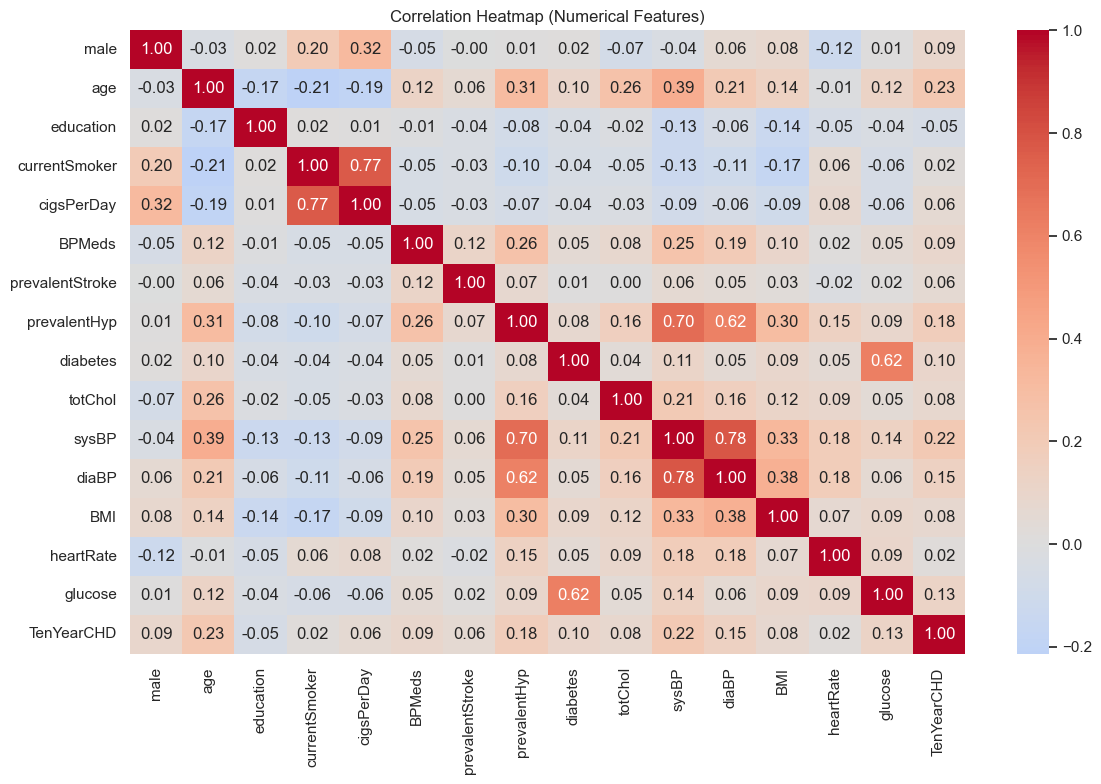

Correlation with target:


,corr_with_target
age,0.225408
sysBP,0.216374
prevalentHyp,0.177458
diaBP,0.145112
glucose,0.125590
diabetes,0.097344
male,0.088374
BPMeds,0.087519
totChol,0.082369
BMI,0.075300


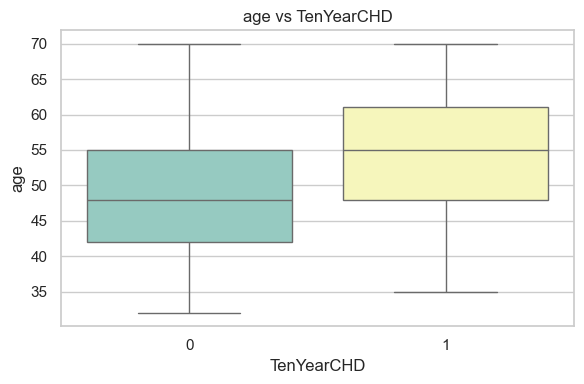

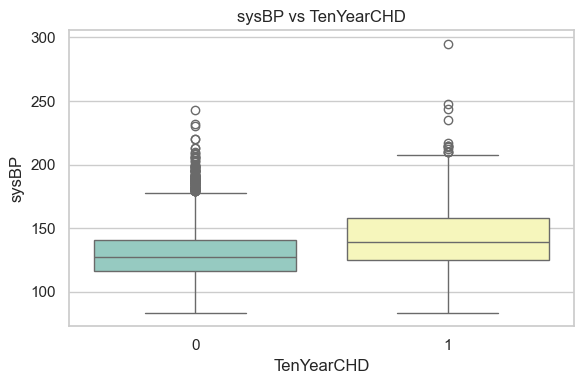

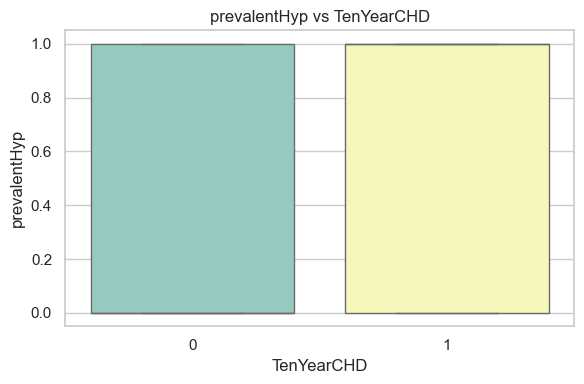

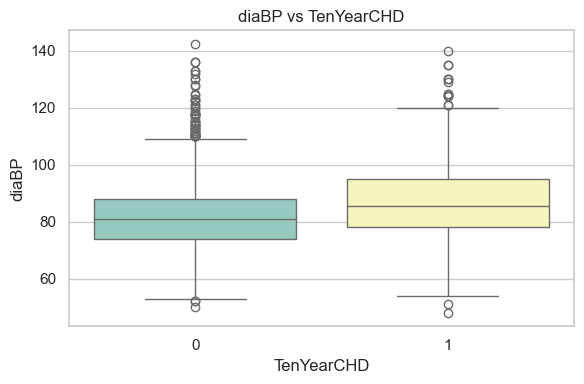

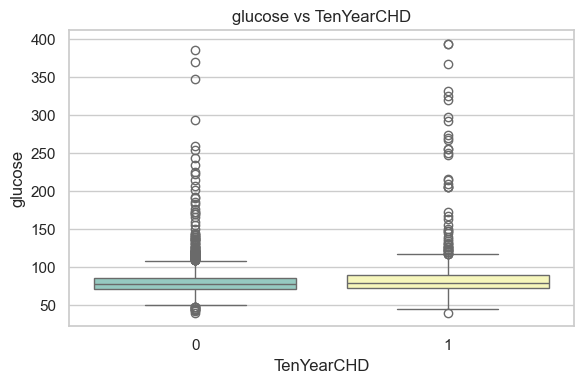

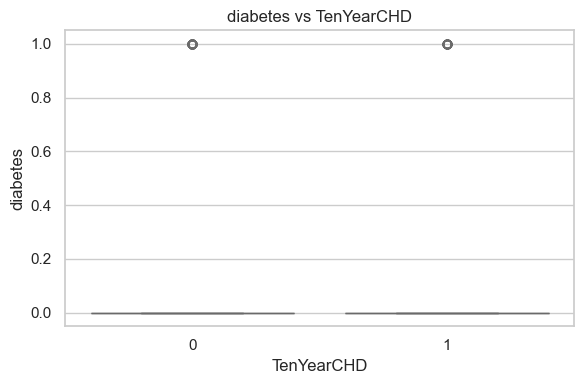

In [19]:
# Correlation analysis
if len(num_cols) > 1:
    corr_matrix = eda_df[num_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Numerical Features)')
    plt.tight_layout()
    plt.show()

    if target_col and target_col in corr_matrix.columns:
        target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
        print('Correlation with target:')
        display(target_corr.to_frame('corr_with_target'))

        top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
        for feature in top_features:
            plt.figure(figsize=(6, 4))
            sns.boxplot(x=target_col, y=feature, data=eda_df, palette='Set3')
            plt.title(f'{feature} vs {target_col}')
            plt.tight_layout()
            plt.show()

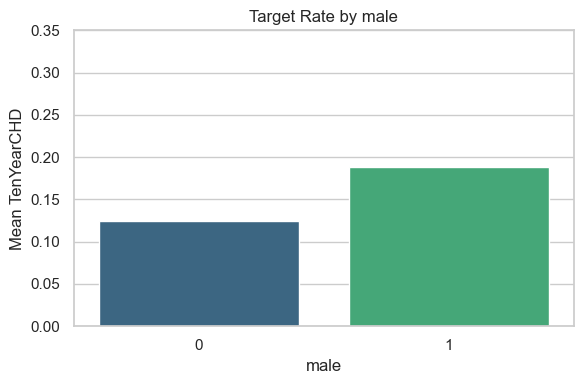

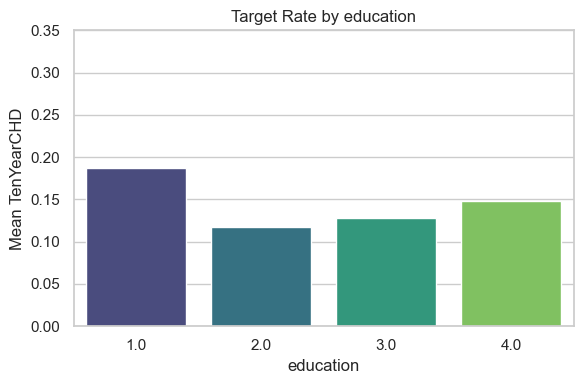

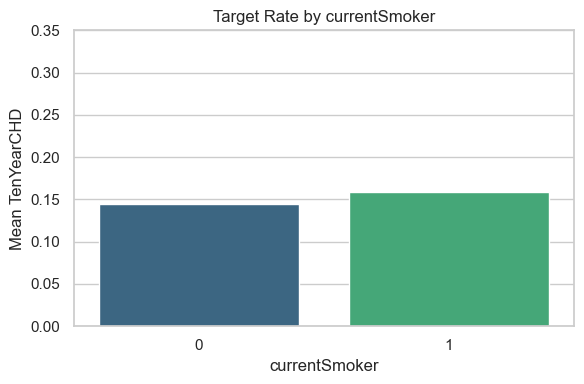

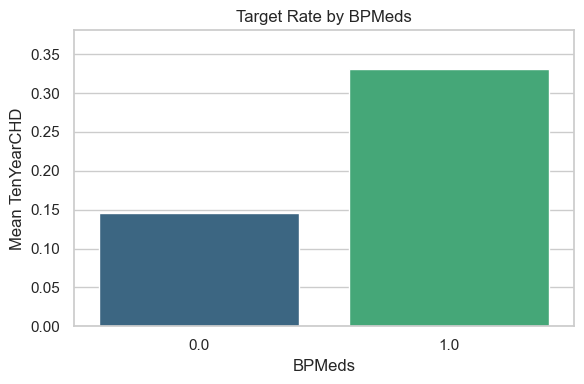

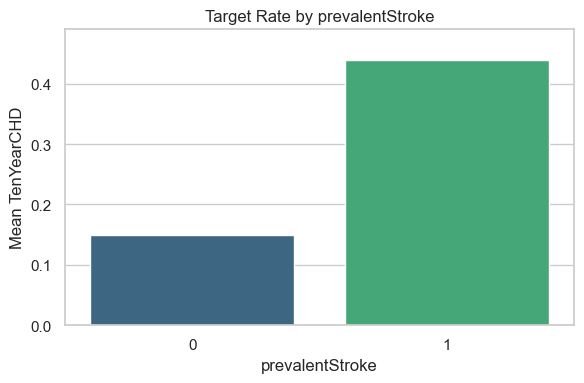

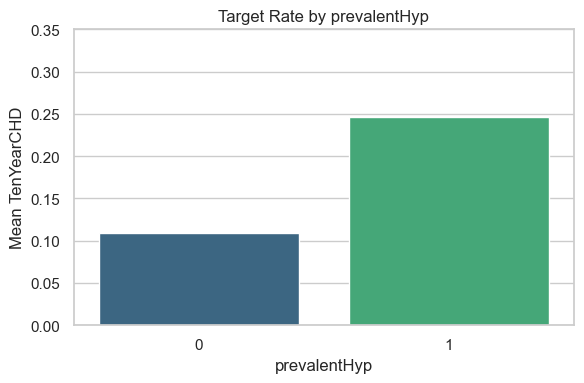

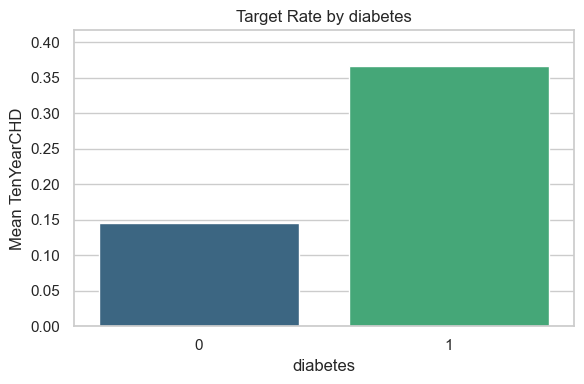

Target rate by low-cardinality features:


,male,target_rate,feature,education,currentSmoker,BPMeds,prevalentStroke,prevalentHyp,diabetes
13,NaN,0.440000,prevalentStroke,NaN,NaN,NaN,1.0,NaN,NaN
17,NaN,0.366972,diabetes,NaN,NaN,NaN,NaN,NaN,1.0
10,NaN,0.330645,BPMeds,NaN,NaN,1.0,NaN,NaN,NaN
15,NaN,0.246773,prevalentHyp,NaN,NaN,NaN,NaN,1.0,NaN
11,NaN,0.207547,BPMeds,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,0.188462,male,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,0.187791,education,1.0,NaN,NaN,NaN,NaN,NaN
8,NaN,0.158950,currentSmoker,NaN,1.0,NaN,NaN,NaN,NaN
6,NaN,0.152381,education,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,0.150178,prevalentStroke,NaN,NaN,NaN,0.0,NaN,NaN


In [20]:
# Binary/low-cardinality categorical relationships with target
binary_like_cols = [c for c in eda_df.columns if eda_df[c].nunique(dropna=True) <= 5 and c != target_col]

if target_col and binary_like_cols:
    risk_table = []
    for col in binary_like_cols:
        grouped = eda_df.groupby(col, dropna=False)[target_col].mean().reset_index()
        grouped['feature'] = col
        grouped = grouped.rename(columns={target_col: 'target_rate'})
        risk_table.append(grouped)

        plt.figure(figsize=(6, 4))
        sns.barplot(data=grouped, x=col, y='target_rate', palette='viridis')
        plt.title(f'Target Rate by {col}')
        plt.ylabel(f'Mean {target_col}')
        plt.ylim(0, max(0.35, grouped['target_rate'].max() + 0.05))
        plt.tight_layout()
        plt.show()

    risk_df = pd.concat(risk_table, ignore_index=True)
    print('Target rate by low-cardinality features:')
    display(risk_df.sort_values('target_rate', ascending=False).head(20))

In [21]:
# Outlier diagnostics using IQR
outlier_rows = []
for col in num_cols:
    series = eda_df[col].dropna()
    if series.empty:
        continue
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        outlier_pct = 0.0
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_pct = ((eda_df[col] < lower) | (eda_df[col] > upper)).mean() * 100

    outlier_rows.append({'feature': col, 'outlier_pct': round(outlier_pct, 2)})

outlier_report = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
print('Outlier percentage by feature (IQR method):')
display(outlier_report)

# Quick EDA summary
print('\n=== EDA Summary ===')
print(f'Total rows: {rows}, columns: {cols}')
print(f'Duplicate rows: {eda_df.duplicated().sum()}')

if target_col:
    positive_rate = eda_df[target_col].mean() * 100
    print(f'{target_col} positive class rate: {positive_rate:.2f}%')

most_missing = missing_pct.sort_values(ascending=False).head(5)
print('\nTop 5 columns by missing %:')
print(most_missing)

if target_col and 'target_corr' in locals():
    print('\nTop 5 absolute correlations with target:')
    print(target_corr.abs().sort_values(ascending=False).head(5))

Outlier percentage by feature (IQR method):


,feature,outlier_pct
14,glucose,4.43
10,sysBP,2.97
12,BMI,2.29
11,diaBP,1.82
13,heartRate,1.79
9,totChol,1.32
4,cigsPerDay,0.28
0,male,0.00
1,age,0.00
2,education,0.00



=== EDA Summary ===
Total rows: 4240, columns: 16
Duplicate rows: 0
TenYearCHD positive class rate: 15.19%

Top 5 columns by missing %:
glucose       9.15
education     2.48
BPMeds        1.25
totChol       1.18
cigsPerDay    0.68
dtype: float64

Top 5 absolute correlations with target:
age             0.225408
sysBP           0.216374
prevalentHyp    0.177458
diaBP           0.145112
glucose         0.125590
Name: TenYearCHD, dtype: float64


## Create Complete Dataset for Model Training

This block creates a fully complete (no missing values) dataset and saves it for model training.

In [22]:
# Create complete dataset (no missing values) for training
train_df = pd.read_csv('data.csv', na_values=['NA', 'na', 'N/A', ''])

# Ensure numeric conversion where possible
for col in train_df.columns:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

# Columns by type/role
target_column = 'TenYearCHD'
binary_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', target_column]
ordinal_cols = ['education']

continuous_cols = [c for c in train_df.columns if c not in binary_cols + ordinal_cols]

# Impute missing values
# 1) Binary + target: mode (most frequent)
for col in binary_cols:
    if col in train_df.columns and train_df[col].isna().any():
        train_df[col] = train_df[col].fillna(train_df[col].mode(dropna=True)[0])

# 2) Ordinal: mode
for col in ordinal_cols:
    if col in train_df.columns and train_df[col].isna().any():
        train_df[col] = train_df[col].fillna(train_df[col].mode(dropna=True)[0])

# 3) Continuous: median
for col in continuous_cols:
    if train_df[col].isna().any():
        train_df[col] = train_df[col].fillna(train_df[col].median())

# Cast integer-like columns to int for clean training schema
for col in binary_cols + ordinal_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].round().astype(int)

# Final validation and export
missing_after = train_df.isna().sum().sum()
output_path = 'data_for_model_training.csv'
train_df.to_csv(output_path, index=False)

print(f'Output file: {output_path}')
print(f'Shape: {train_df.shape}')
print(f'Total missing values after processing: {missing_after}')
print('\nMissing values by column (should all be 0):')
print(train_df.isna().sum())

print('\nTarget distribution in final dataset:')
print(train_df[target_column].value_counts().sort_index())

display(train_df.head())

Output file: data_for_model_training.csv
Shape: (4240, 16)
Total missing values after processing: 0

Missing values by column (should all be 0):
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Target distribution in final dataset:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [23]:
train_df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64